 # Experiment 1: Initial DMP framework


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

#################################################<br>
Load and plot 2D demonstrations<br>
#################################################

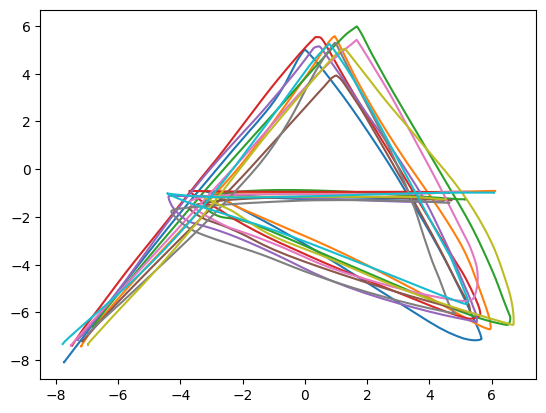

[-7.77163904 -7.76859926 -7.77100978 -7.77110999 -7.762105   -7.75073852
 -7.73194731 -7.69936785 -7.6447041  -7.55969552 -7.43702732 -7.27069189
 -7.05734426 -6.79649782 -6.4900221  -6.14215301 -5.76034591 -5.3539674
 -4.93084906 -4.49657647 -4.05913869 -3.63152115 -3.23024427 -2.86637995
 -2.54230241 -2.25266356 -1.98890008 -1.7416559  -1.50449403 -1.27840595
 -1.06894692 -0.87814447 -0.70104457 -0.52979964 -0.36125458 -0.20059099
 -0.06012674  0.0486279   0.12651108  0.18762536  0.24867674  0.31553636
  0.38307297  0.44436731  0.49790423  0.54653736  0.59230803  0.63440032
  0.67064083  0.70003815  0.72320235  0.74164746  0.75673704  0.76956053
  0.78170768  0.79641598  0.81874772  0.85479889  0.91069881  0.99129349
  1.09847706  1.23129438  1.3877      1.56616493  1.76563367  1.98442691
  2.21933553  2.46549653  2.71733048  2.97044561  3.2215833   3.46648841
  3.69827242  3.90931506  4.09516516  4.2552161   4.39071003  4.50315485
  4.59440474  4.66717583  4.72563277  4.77549848  4.

In [17]:
mat = loadmat('2Dletters/A.mat')
demosNum = 10 # numnber of data sets
dataset = []
for i in range(demosNum):
    data = mat['demos'][0, i]['pos'][0, 0]
    dataset.append(data)
    plt.plot(data[0], data[1])
plt.show()
print(data[0])
print(data[1])
print(data.shape) # 2 rows, 400 coloumns


##################################################<br>
Calculate velocity and acceleration from the position profile<br>
##################################################

In [18]:
dt = 0.005 # time interval
dim = 2   # 2D trajectory
pos = dataset[0] # only use the first demonstration for learning
tau = dt * pos.shape[1] # motion duration
vel = np.gradient(pos, axis=-1)/dt # velocity using derivative
acc = np.gradient(vel, axis=-1)/dt # acceleration
goal = pos[:, -1] # the end-point of the demonstration (final pos)

print(tau)

1.0


#################################################<br>
Set DMP parameters and basis functions<br>
#################################################

In [19]:
kp = 150.0 # constants used in the final equation
kv = 25.0
alpha = 5 # spreding value
basis_num = 40  # number of basis functions (num of gaussians)
u = np.zeros(basis_num)
c = np.zeros(basis_num) # centers of basis functions
h = np.zeros(basis_num) # widths of basis functions
for i in range(basis_num):
    u[i] = (1.0 / basis_num) * i # linear spead of numbers from 0 to 1 in exactly 40 steps eg. 0.0, 0.025, 0.05 ex
    c[i] = np.exp(-alpha * u[i]) #  exponential spead(smalled gaps as C increases)
for i in range(basis_num-1):
    h[i] = 0.5 / ((0.65 * (c[i+1] - c[i]))**2) # spread of each gaussian using the distnace between the centers
h[basis_num-1] = h[basis_num-2] # last two have equal spead

#################################################<br>
Estimate DMP pattern w<br>
#################################################

In [20]:
iterNum = int(np.round(tau / dt)) # this is how many time steps the demo has
Phi = np.zeros(basis_num) # temporary vector to store the value of all basis functions ψ at one moment.
Phi_total = np.zeros((iterNum, basis_num)) # a big matrix to store every time step’s feature vector.

force = np.zeros((iterNum, dim)) # stores forcing value for each inetrval

In [21]:
s = 1  # phase variable
for i in range(iterNum): # for the number of iteration
    s = -alpha * s * dt / tau + s # iteration in the canonical system, each time it moves forward by one dt
    #print(s)
    #print(tau)
    addsum = 0
    for b in range(basis_num): # for the numebr of gaussians
        Phi[b] = np.exp(-h[b] * (s - c[b]) ** 2) # initializes the gasuain using it's ceneter and S.D. (width H)
        addsum = addsum + Phi[b]
    Phi = Phi / addsum * s
    Phi_total[i, :] = Phi # stores the feature vector for each time step in a big matrix
    force[i, :] = tau * tau * acc[:, i] - kp * (goal - pos[:, i]) + tau * kv * vel[:, i] # calculates the forcing term for each time step using the given equation


In [22]:
trainPattern = np.matmul(np.linalg.pinv(Phi_total), force) # gets weights using data

#print(trainPattern)
print(trainPattern.shape)

(40, 2)


#################################################<br>
Prediction using DMP<br>
#################################################<br>

In [23]:
iniPos = np.array([pos[0, 0], pos[1, 0]])    
iniVel = np.array([0, 0])                    
newGoal = np.array([pos[0, -1], pos[1, -1]]) 
newTau = tau                                 

In [24]:
newLen = int(np.round(newTau / dt))
DMP_pos = np.zeros((dim, newLen))
DMP_vel = np.zeros((dim, newLen))
DMP_acc = np.zeros((dim, newLen))
s = 1 # phase variable
for i in range(newLen-1):# for new num of iterations
    s = -alpha * s * dt / newTau + s # iteration in the canonical system, each time it moves forward by one dt
    if i == 0:
        DMP_pos[:, 0] = iniPos # setting new starting pos
        DMP_vel[:, 0] = iniVel
    addsum = 0
    for b in range(basis_num): #for each gaussian
        Phi[b] = np.exp(-h[b] * (s - c[b]) ** 2)
        addsum = addsum + Phi[b]
    newForce = np.matmul(Phi/addsum, trainPattern) * s ## multiply each 

    # Iteration in the 2nd-order transformation system
    DMP_acc[:, i] = (kp * (newGoal - DMP_pos[:, i]) - newTau * kv * DMP_vel[:, i] + newForce) / newTau**2
    DMP_pos[:, i+1] = DMP_pos[:, i] + DMP_vel[:, i] * dt # update position using velocity
    DMP_vel[:, i+1] = DMP_vel[:, i] + DMP_acc[:, i] * dt # update velocity using acceleration

#################################################<br>
Plot predicted trajectories<br>
#################################################-

In [25]:
t0 = np.linspace(dt, tau, num=int(np.round(tau/dt)))
t = np.linspace(dt, newTau, num=int(np.round(newTau/dt)))

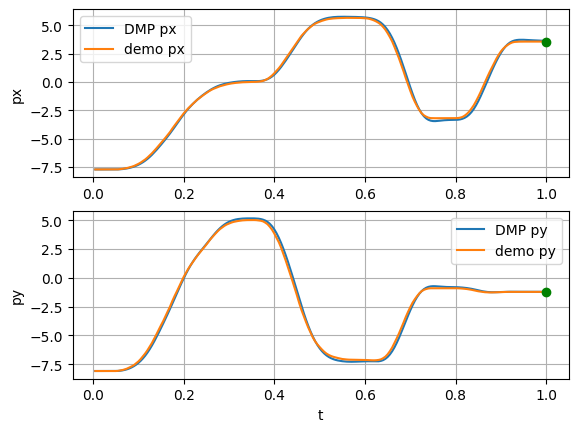

In [26]:
ax1 = plt.subplot(2, 1, 1)
ax1.plot(t, DMP_pos[0, :], label='DMP px')
ax1.plot(t0, pos[0, :], label='demo px')
ax1.plot(newTau, newGoal[0], 'go')
ax1.set_ylabel("px")
plt.legend()
ax1.grid()
ax2 = plt.subplot(2, 1, 2)
ax2.plot(t, DMP_pos[1, :], label='DMP py')
ax2.plot(t0, pos[1, :], label='demo py')
ax2.plot(newTau, newGoal[1], 'go')
ax2.set_xlabel("t")
ax2.set_ylabel("py")
plt.legend()
ax2.grid()
plt.show()

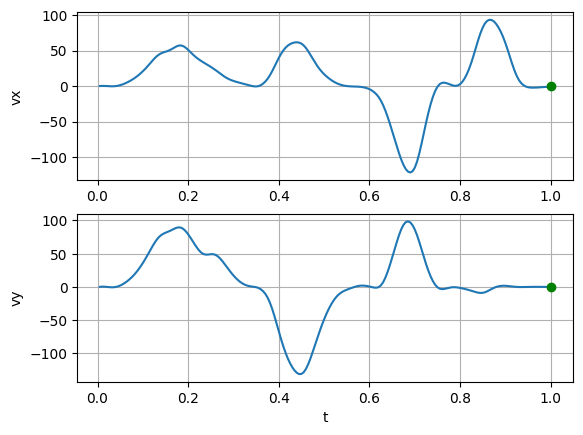

In [27]:
ax1 = plt.subplot(2, 1, 1)
ax1.plot(t, DMP_vel[0, :])
ax1.plot(newTau, 0, 'go')
ax1.set_ylabel("vx")
ax1.grid()
ax2 = plt.subplot(2, 1, 2)
ax2.plot(t, DMP_vel[1, :])
ax2.plot(newTau, 0, 'go')
ax2.set_xlabel("t")
ax2.set_ylabel("vy")
ax2.grid()
plt.show()

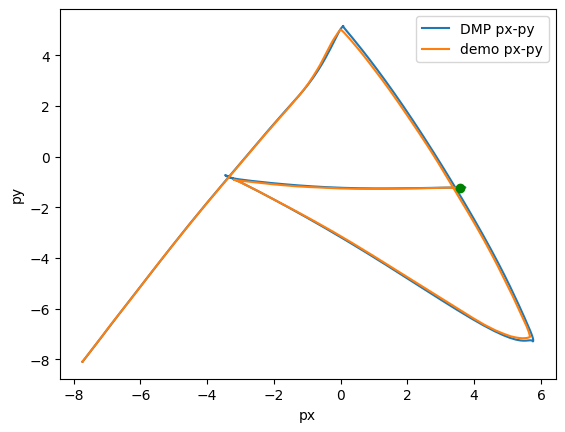

In [28]:
plt.plot(DMP_pos[0, :], DMP_pos[1, :], label='DMP px-py')    # DMP trajectory
plt.plot(pos[0,:], pos[1, :], label='demo px-py')      # demonstration
plt.plot(newGoal[0], newGoal[1], 'go')
plt.xlabel("px")
plt.ylabel("py")
plt.legend()
plt.show()

#################################################<br>
Performance Evaluation<br>
#################################################

In [29]:
from Performance_measuring import test_dmp_performance

point_error, metrics = test_dmp_performance(
    original_path=pos,
    DMP_path=DMP_pos,
)

for key, value in metrics.items():
    print(f"{key}: {value}")

final_goal_error: 0.06969140023149127
RMS_tracking_error: 0.2417216251947871
min_distance_each_obstacle: []
min_distance_overall: None
original_path_length: 46.43679712684595
DMP_path_length: 47.926321887107015


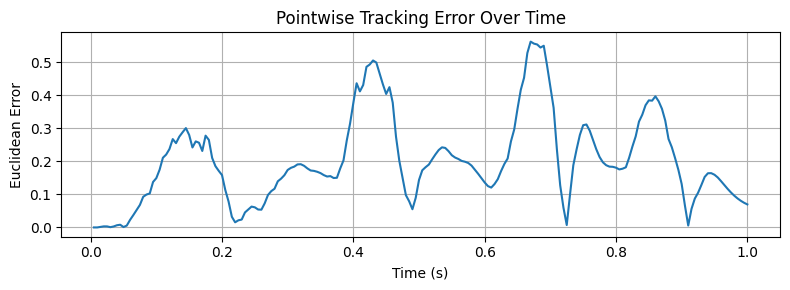

In [30]:
plt.figure(figsize=(8, 3))
plt.plot(t, point_error)
plt.xlabel('Time (s)')
plt.ylabel('Euclidean Error')
plt.title('Pointwise Tracking Error Over Time')
plt.grid(True)
plt.tight_layout()
plt.show()